# Twitter A/B Testing — Experiment Analysis

## Purpose
This notebook analyzes the supplied Twitter advertising experiment using the variables actually available in the dataset.

**Control:** traditional click-based product  
**Treatment:** new impression-based product

The primary business question is whether the treatment reduces campaign overspending.

> **Important data limitation:** the supplied dataset contains only `treatment`, `company_size`, `campaign_spend`, and `campaign_budget`. It does **not** contain clicks, impressions, likes, retweets, replies, or industry. Therefore CTR, engagement, and industry-level analysis cannot be calculated from these files.


### Analytical standard
This notebook is structured as a product-facing experimentation analysis: business context → data validation → exploratory evidence → primary treatment effect → heterogeneity → budget behavior → secondary outcomes → limitations → recommendation.


## Executive summary

**Primary question:** Does the impression-based treatment reduce campaign overspending relative to the traditional click-based product?

The analysis evaluates both the incidence of campaigns exceeding the assignment's >1% overspend threshold and the distribution of overspend percentage. Company size is treated as a potential effect modifier, with an explicit treatment × company-size interaction rather than relying only on separate subgroup tests.

**Interpretation discipline:** statistically significant differences are reported separately from practical magnitude, and observational differences such as budget differences are not attributed to advertiser motivation without supporting evidence.

**Data limitations:** the supplied dataset does not include clicks, impressions, engagement metrics, or industry, so CTR, likes/retweets/replies, and industry-level comparisons cannot be calculated.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\EDA-2 project_task\Twitter A_B testing.csv")
df.head()


# Professional plotting defaults
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

CONTROL = "Control"
TREATMENT = "Treatment"
SIZE_ORDER = ["small", "medium", "large"]
GROUP_ORDER = [CONTROL, TREATMENT]


## 1. Data understanding and quality checks

Each row represents a campaign. We first verify the dataset structure before calculating any outcomes.


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTreatment counts:")
print(df["treatment"].value_counts())

print("\nCompany-size counts:")
print(df["company_size"].value_counts())

print("\nNon-positive budgets:", (df["campaign_budget"] <= 0).sum())
print("Negative spend:", (df["campaign_spend"] <= 0).sum())


Shape: (15474, 4)

Columns:
['treatment', 'company_size', 'campaign_spend', 'campaign_budget']

Data types:
treatment             bool
company_size        object
campaign_spend     float64
campaign_budget    float64
dtype: object

Missing values:
treatment          0
company_size       0
campaign_spend     0
campaign_budget    0
dtype: int64

Duplicate rows: 0

Treatment counts:
treatment
True     7741
False    7733
Name: count, dtype: int64

Company-size counts:
company_size
small     8901
large     5146
medium    1427
Name: count, dtype: int64

Non-positive budgets: 0
Negative spend: 0


## 2. Feature engineering

We distinguish **budget deviation** from **actual overspend**.

- `overspend_pct` is the signed percentage difference between spend and budget. A negative value means the campaign underspent.
- `actual_overspend_pct` sets underspending to zero and measures only the amount above budget.
- The assignment's primary threshold is **more than 1% over budget**.


In [3]:
df["group"] = np.where(df["treatment"], "Treatment", "Control")

df["overspend_amount"] = df["campaign_spend"] - df["campaign_budget"]
df["overspend_pct"] = (
    df["overspend_amount"] / df["campaign_budget"] * 100
)
df["actual_overspend_pct"] = df["overspend_pct"].clip(lower=0)
df["overspent_gt1pct"] = df["overspend_pct"] > 1
df["budget_spent_pct"] = (
    df["campaign_spend"] / df["campaign_budget"] * 100
)

df["log_spend"] = np.log1p(df["campaign_spend"])
df["log_budget"] = np.log1p(df["campaign_budget"])

df[[
    "group", "company_size", "campaign_spend", "campaign_budget",
    "overspend_amount", "overspend_pct",
    "actual_overspend_pct", "overspent_gt1pct", "budget_spent_pct"
]].head()


,group,company_size,campaign_spend,campaign_budget,overspend_amount,overspend_pct,actual_overspend_pct,overspent_gt1pct,budget_spent_pct
0,Control,small,10.4477,3.9035,6.5442,167.6495,167.6495,True,267.6495
1,Control,medium,3.7776,1.9872,1.7904,90.0966,90.0966,True,190.0966
2,Control,medium,46.1880,55.4523,-9.2643,-16.7068,0.0000,False,83.2932
3,Control,small,6.6271,6.5136,0.1135,1.7425,1.7425,True,101.7425
4,Control,small,92.3405,83.1018,9.2387,11.1173,11.1173,True,111.1173


## 3. Experiment allocation / sanity check

The treatment and control groups are nearly equal in size. We also inspect company-size composition.

Small differences in randomized groups are not automatically evidence of a problem; the purpose here is to understand the sample before interpreting outcomes.


In [4]:
allocation = (
    df.groupby("group")
      .size()
      .rename("campaigns")
      .to_frame()
)
allocation["share"] = allocation["campaigns"] / len(df)
allocation


,campaigns,share
group,,
Control,7733,0.4997
Treatment,7741,0.5003


In [5]:
size_allocation = pd.crosstab(
    df["company_size"], df["group"], normalize="columns"
) * 100
size_allocation.round(2)


group,Control,Treatment
company_size,,
large,34.9300,31.5900
medium,9.5000,8.9400
small,55.5700,59.4800


## 4. Exploratory analysis

Spend and budget are highly right-skewed, so we use medians and log-scale visualizations alongside means. We do not remove extreme observations merely because they are large: those observations are part of the observed campaign behavior.


In [6]:
summary = (
    df.groupby("group")
      .agg(
          campaigns=("campaign_spend", "size"),
          mean_spend=("campaign_spend", "mean"),
          median_spend=("campaign_spend", "median"),
          mean_budget=("campaign_budget", "mean"),
          median_budget=("campaign_budget", "median"),
          mean_overspend_pct=("overspend_pct", "mean"),
          median_overspend_pct=("overspend_pct", "median"),
          mean_actual_overspend_pct=("actual_overspend_pct", "mean"),
          median_actual_overspend_pct=("actual_overspend_pct", "median"),
          mean_budget_spent_pct=("budget_spent_pct", "mean"),
          median_budget_spent_pct=("budget_spent_pct", "median"),
      )
)
summary


,campaigns,mean_spend,median_spend,mean_budget,median_budget,mean_overspend_pct,median_overspend_pct,mean_actual_overspend_pct,median_actual_overspend_pct,mean_budget_spent_pct,median_budget_spent_pct
group,,,,,,,,,,,
Control,7733,"3,950.8497",64.5492,"4,641.8276",65.3784,25.3226,6.4551,31.3230,6.4551,125.3226,106.4551
Treatment,7741,"5,854.2398",38.4434,"6,902.2326",38.5950,17.6064,4.6265,25.9334,4.6265,117.6064,104.6265


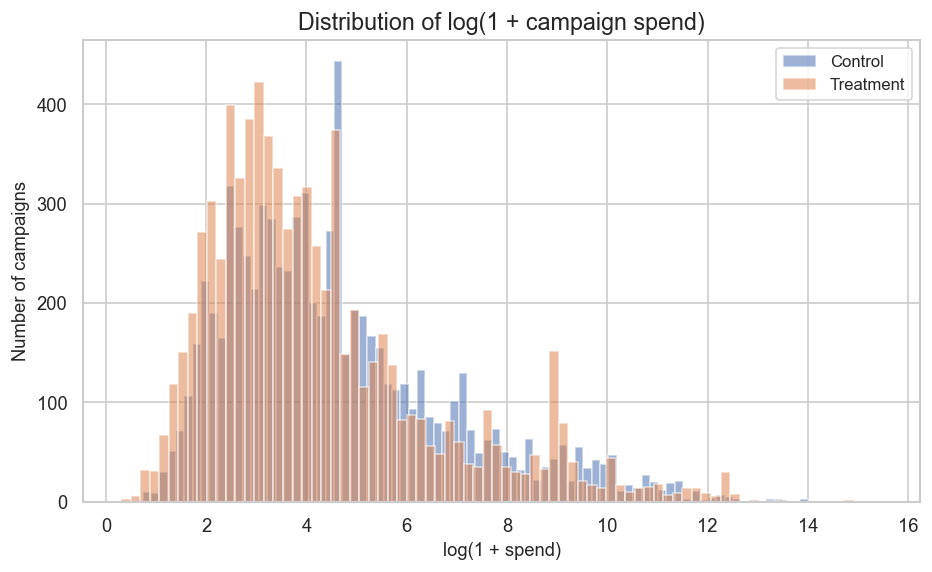

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for group in ["Control", "Treatment"]:
    values = df.loc[df["group"] == group, "campaign_spend"]
    ax.hist(np.log1p(values), bins=80, alpha=0.55, label=group)
ax.set_title("Distribution of log(1 + campaign spend)")
ax.set_xlabel("log(1 + spend)")
ax.set_ylabel("Number of campaigns")
ax.legend()
plt.show()


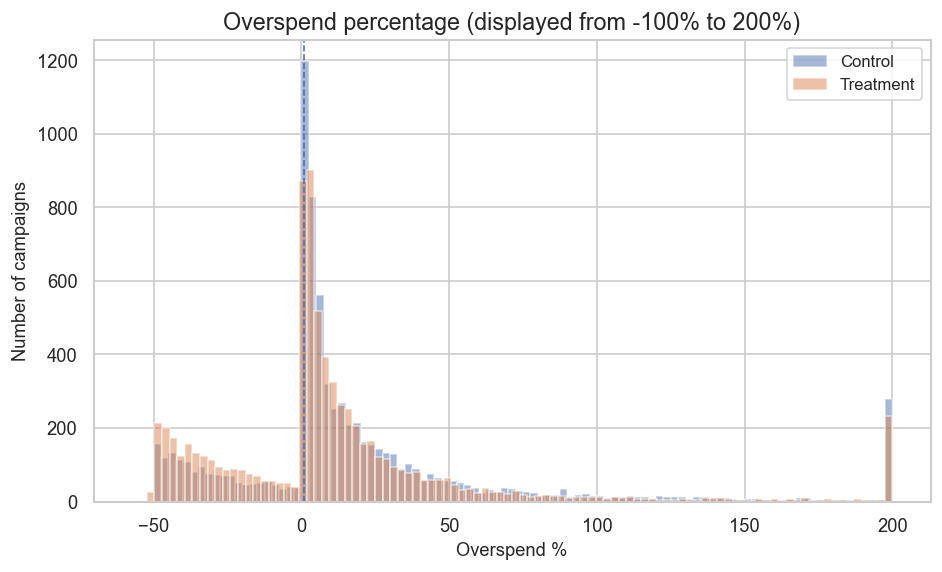

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for group in ["Control", "Treatment"]:
    values = df.loc[df["group"] == group, "overspend_pct"]
    clipped = values.clip(-100, 200)
    ax.hist(clipped, bins=100, alpha=0.5, label=group)
ax.axvline(1, linestyle="--", linewidth=1)
ax.set_title("Overspend percentage (displayed from -100% to 200%)")
ax.set_xlabel("Overspend %")
ax.set_ylabel("Number of campaigns")
ax.legend()
plt.show()


# Question 1 — Campaigns overspending by more than 1%

The assignment asks for the number of campaigns with overspend greater than 1% of budget in each group. We report both counts and rates because group sizes are slightly different.


In [9]:
q1 = (
    df.groupby("group")["overspent_gt1pct"]
      .agg(campaigns="size", overspent="sum")
)
q1["rate_pct"] = q1["overspent"] / q1["campaigns"] * 100
q1


,campaigns,overspent,rate_pct
group,,,
Control,7733,5716,73.9170
Treatment,7741,5180,66.9164


### Statistical comparison of overspend incidence

**H₀:** The proportion of campaigns overspending by more than 1% is equal between groups.

**H₁:** The proportions differ.

We also calculate the treatment-control difference in percentage points and a confidence interval.


In [10]:
control = df.loc[df["group"] == "Control", "overspent_gt1pct"]
treatment = df.loc[df["group"] == "Treatment", "overspent_gt1pct"]

count = np.array([treatment.sum(), control.sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(count, nobs)

# Treatment - Control risk difference and approximate 95% CI
p_t = treatment.mean()
p_c = control.mean()
rd = p_t - p_c
se_rd = np.sqrt(
    p_t * (1 - p_t) / len(treatment)
    + p_c * (1 - p_c) / len(control)
)
ci_rd = (rd - 1.96 * se_rd, rd + 1.96 * se_rd)

print(f"Treatment rate: {p_t:.4%}")
print(f"Control rate:   {p_c:.4%}")
print(f"Difference (Treatment - Control): {rd:.4%}")
print(f"95% CI for difference: ({ci_rd[0]:.4%}, {ci_rd[1]:.4%})")
print(f"z = {z_stat:.3f}, p = {p_value:.3e}")


Treatment rate: 66.9164%
Control rate:   73.9170%
Difference (Treatment - Control): -7.0006%
95% CI for difference: (-8.4346%, -5.5665%)
z = -9.540, p = 1.432e-21


### Interpretation

A lower treatment rate indicates fewer campaigns crossed the >1% overspend threshold. Statistical significance tells us whether the observed difference is unlikely under equal underlying rates; the percentage-point difference describes its practical magnitude.


### Visual — Primary experiment outcome

The chart below gives the product manager the quickest view of the primary outcome: the share of campaigns exceeding budget by more than 1%. Counts are shown separately in the Q1 table; the rate is the more useful comparison because the two experiment groups are not exactly the same size.

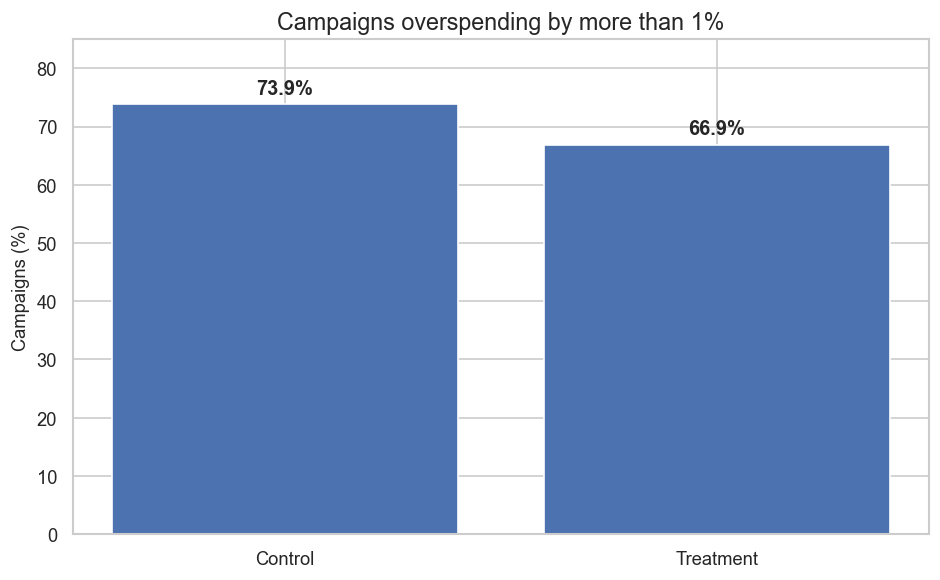

In [11]:
# Primary outcome: >1% overspend rate
plot_df = q1.reset_index()
plot_df["group"] = pd.Categorical(plot_df["group"], categories=GROUP_ORDER, ordered=True)
plot_df = plot_df.sort_values("group")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_df["group"], plot_df["rate_pct"])
ax.set_title("Campaigns overspending by more than 1%")
ax.set_ylabel("Campaigns (%)")
ax.set_xlabel("")
ax.set_ylim(0, 85)

for bar, value in zip(bars, plot_df["rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.1f}%",
            ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


# Question 2 — Did treatment reduce overspending, and does the effect depend on company size?

We evaluate the treatment effect in two ways:

1. The binary primary outcome: whether a campaign overspent by more than 1%.
2. The continuous overspend percentage, using a non-parametric comparison because the distribution is strongly skewed.

For company size, we **do not** infer heterogeneous treatment effects merely from separate p-values. We also fit an explicit treatment × company-size interaction model.


In [12]:
size_results = []

for size in ["small", "medium", "large"]:
    c = df.loc[
        (df["company_size"] == size) & (df["group"] == "Control"),
        "overspent_gt1pct"
    ]
    t = df.loc[
        (df["company_size"] == size) & (df["group"] == "Treatment"),
        "overspent_gt1pct"
    ]

    z, p = proportions_ztest([t.sum(), c.sum()], [len(t), len(c)])
    size_results.append({
        "company_size": size,
        "control_rate_pct": c.mean() * 100,
        "treatment_rate_pct": t.mean() * 100,
        "difference_pp": (t.mean() - c.mean()) * 100,
        "p_value": p
    })

pd.DataFrame(size_results)


,company_size,control_rate_pct,treatment_rate_pct,difference_pp,p_value
0,small,78.8690,70.8514,-8.0175,0.0000
1,medium,61.4966,59.8266,-1.6700,0.5186
2,large,69.4187,61.5133,-7.9054,0.0000


### Visual — Treatment effect by company size

This view shows the treatment and control overspend rates side by side for each company-size segment. It complements the formal interaction model: the chart is descriptive, while the interaction terms test whether the differences between treatment effects are statistically distinguishable.

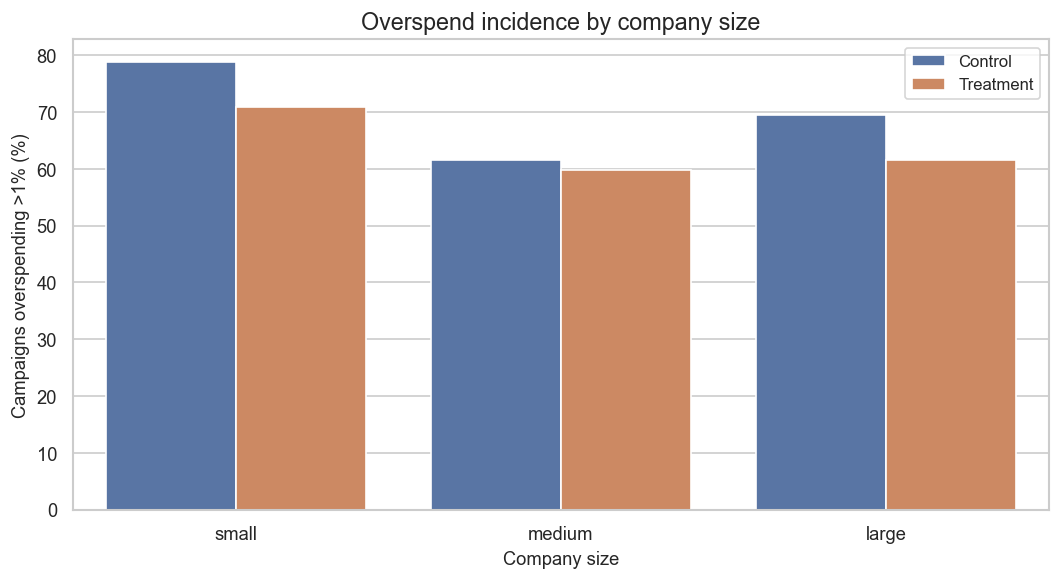

In [13]:
# Overspend >1% rate by company size and experiment group
size_rate = (
    df.groupby(["company_size", "group"], observed=False)["overspent_gt1pct"]
      .mean()
      .mul(100)
      .reset_index()
)
size_rate["company_size"] = pd.Categorical(
    size_rate["company_size"], categories=SIZE_ORDER, ordered=True
)
size_rate["group"] = pd.Categorical(
    size_rate["group"], categories=GROUP_ORDER, ordered=True
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=size_rate, x="company_size", y="overspent_gt1pct",
    hue="group", order=SIZE_ORDER, hue_order=GROUP_ORDER, ax=ax
)
ax.set_title("Overspend incidence by company size")
ax.set_xlabel("Company size")
ax.set_ylabel("Campaigns overspending >1% (%)")
ax.legend(title="")
plt.tight_layout()
plt.show()


### Continuous overspend comparison by company size

The Mann–Whitney U test answers whether the distribution of overspend percentage differs between treatment and control **within a given company-size segment**. A non-significant result for a segment should not be described as proof of "no effect"; it means the data do not provide sufficient evidence of a difference for that segment.


In [14]:
continuous_results = []

for size in ["small", "medium", "large"]:
    c = df.loc[
        (df["company_size"] == size) & (df["group"] == "Control"),
        "overspend_pct"
    ]
    t = df.loc[
        (df["company_size"] == size) & (df["group"] == "Treatment"),
        "overspend_pct"
    ]

    u, p = stats.mannwhitneyu(t, c, alternative="two-sided")
    continuous_results.append({
        "company_size": size,
        "control_median_pct": c.median(),
        "treatment_median_pct": t.median(),
        "median_difference_pp": t.median() - c.median(),
        "p_value": p
    })

pd.DataFrame(continuous_results)


,company_size,control_median_pct,treatment_median_pct,median_difference_pp,p_value
0,small,12.9946,7.7651,-5.2294,0.0000
1,medium,2.2436,2.4708,0.2272,0.7297
2,large,4.0155,2.5053,-1.5103,0.0000


### Visual — Distribution of overspend percentage

The boxplot focuses on the central distribution while retaining outlier visibility. Because overspend percentage is highly skewed, this is more informative than relying on means alone.

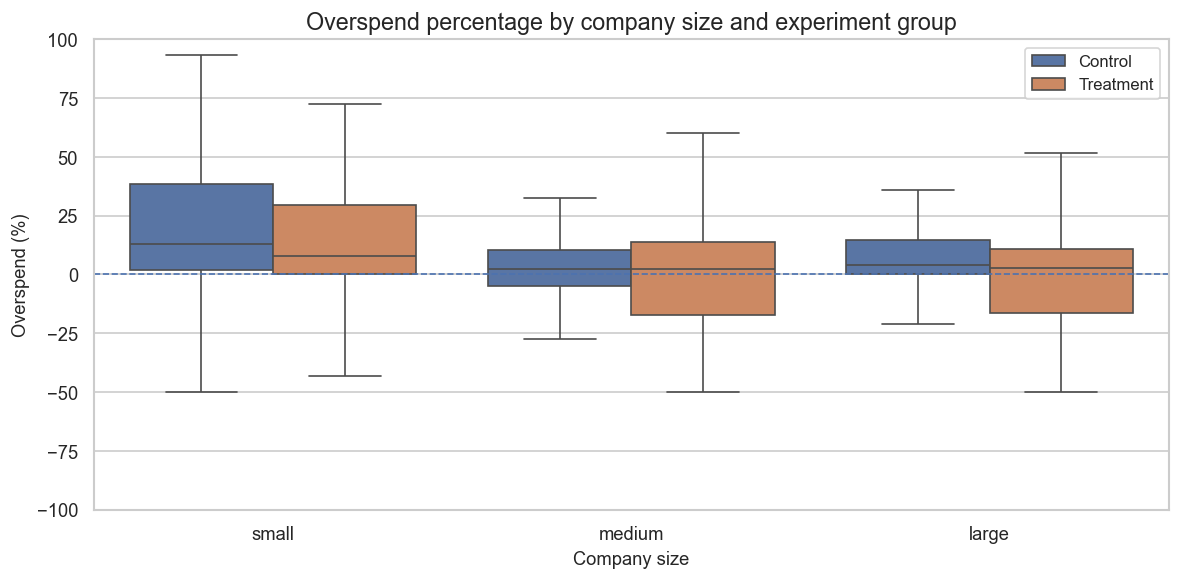

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x="company_size", y="overspend_pct",
    hue="group", order=SIZE_ORDER, hue_order=GROUP_ORDER,
    showfliers=False, ax=ax
)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Overspend percentage by company size and experiment group")
ax.set_xlabel("Company size")
ax.set_ylabel("Overspend (%)")
ax.legend(title="")
plt.ylim(-100, 100)
plt.tight_layout()
plt.show()


### Formal treatment × company-size interaction

A logistic model is used for the >1% overspend indicator:

`overspent_gt1pct ~ treatment + company_size + treatment:company_size`

The interaction terms test whether the treatment effect differs across company sizes. This is the formal way to address the "more or less effective depending on company size" part of the question.


In [16]:
df["overspent_gt1pct"] = df["overspent_gt1pct"].astype(int)

print(df["overspent_gt1pct"].dtype)
print(df["overspent_gt1pct"].unique())

int64
[1 0]


In [17]:
df["treatment_binary"] = df["treatment"].astype(int)
df["overspent_gt1pct"] = df["overspent_gt1pct"].astype(int)
df["company_size"] = df["company_size"].astype("category")

model_q2 = smf.logit(
    "overspent_gt1pct ~ treatment_binary * C(company_size)",
    data=df
).fit(disp=False)

print(model_q2.summary())

                           Logit Regression Results                           
Dep. Variable:       overspent_gt1pct   No. Observations:                15474
Model:                          Logit   Df Residuals:                    15468
Method:                           MLE   Df Model:                            5
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                 0.01647
Time:                        16:03:40   Log-Likelihood:                -9242.8
converged:                       True   LL-Null:                       -9397.5
Covariance Type:            nonrobust   LLR p-value:                 9.248e-65
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.8198      0.042     19.630      0.000       0.738       0.902
C(company_size)[T.medium]          

### Q2 interpretation

The key distinction is:

- A significant treatment coefficient indicates an overall treatment association relative to the model's reference company size.
- A significant interaction indicates that the treatment effect changes by company size.
- Separate segment tests describe where differences are observed, but they are not by themselves a formal test that the effects differ from one another.

We will use the interaction model together with the segment-level estimates when writing the final conclusion.


# Question 3 — Are treatment advertisers entering lower budgets?

The product manager's concern is causal in wording ("because they are wary"). The data can test whether **budgets differ between treatment and control**, but it cannot establish advertisers' motivation or attitude.

Because budgets are heavily skewed, we compare both raw-scale summaries and log-transformed budgets.


In [18]:
budget_summary = (
    df.groupby("group")["campaign_budget"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)
budget_summary


,count,mean,median,std,min,max
group,,,,,,
Control,7733,"4,641.8276",65.3784,"47,765.7538",0.3063,"2,119,520.4790"
Treatment,7741,"6,902.2326",38.5950,"131,623.5441",0.0919,"10,242,888.2100"


In [19]:
# Welch t-test on log(1 + budget)
c_log = df.loc[df["group"] == "Control", "log_budget"]
t_log = df.loc[df["group"] == "Treatment", "log_budget"]

welch_t, welch_p = stats.ttest_ind(t_log, c_log, equal_var=False)

# Mann–Whitney sensitivity analysis on raw budget
u_budget, p_budget = stats.mannwhitneyu(
    df.loc[df["group"] == "Treatment", "campaign_budget"],
    df.loc[df["group"] == "Control", "campaign_budget"],
    alternative="two-sided"
)

print(f"Welch t-test on log(1 + budget): t={welch_t:.3f}, p={welch_p:.3e}")
print(f"Mann–Whitney test on raw budget: U={u_budget:.3e}, p={p_budget:.3e}")


Welch t-test on log(1 + budget): t=-8.189, p=2.849e-16
Mann–Whitney test on raw budget: U=2.697e+07, p=1.467e-26


### Visual — Advertiser budget distributions

The raw budget distribution is extremely right-skewed, so the second panel uses a logarithmic x-axis. This helps us see whether the treatment-control difference is broad-based rather than being driven only by a few very large campaigns.

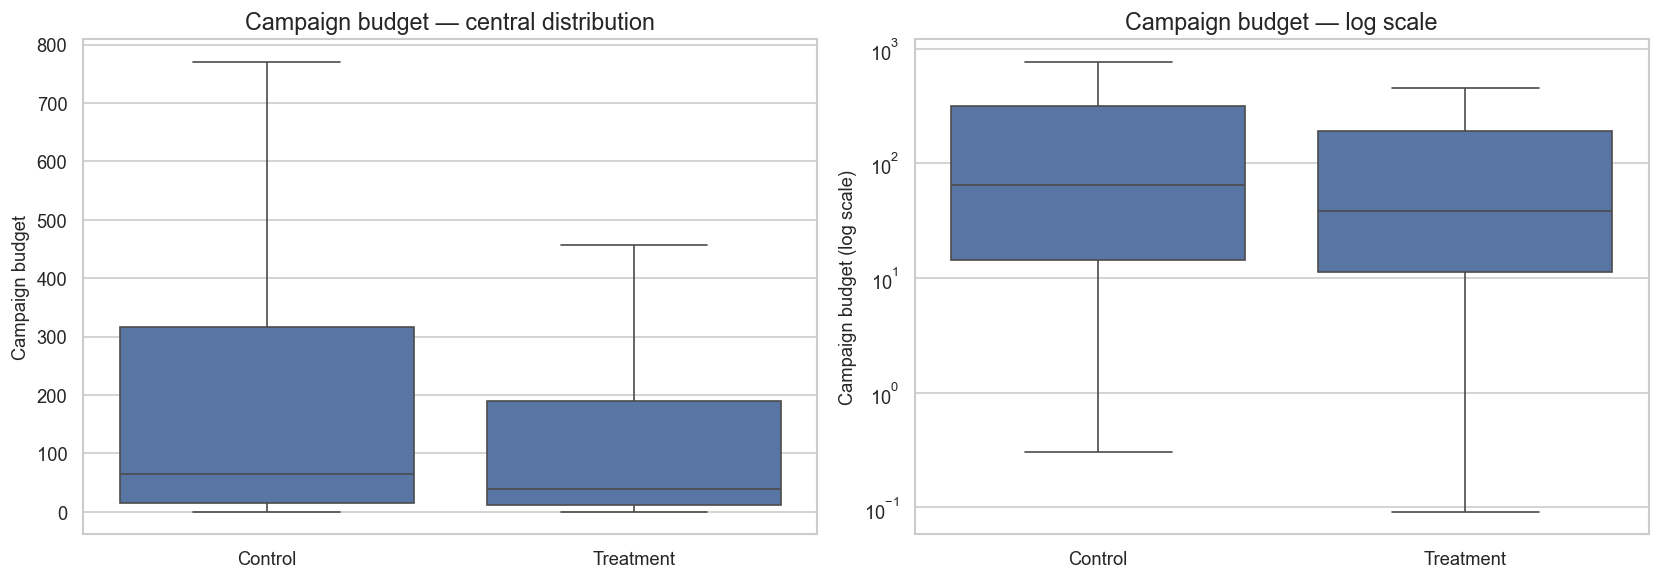

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x="group", y="campaign_budget",
    order=GROUP_ORDER, showfliers=False, ax=axes[0]
)
axes[0].set_title("Campaign budget — central distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Campaign budget")

sns.boxplot(
    data=df, x="group", y="campaign_budget",
    order=GROUP_ORDER, showfliers=False, ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Campaign budget — log scale")
axes[1].set_xlabel("")
axes[1].set_ylabel("Campaign budget (log scale)")

plt.tight_layout()
plt.show()


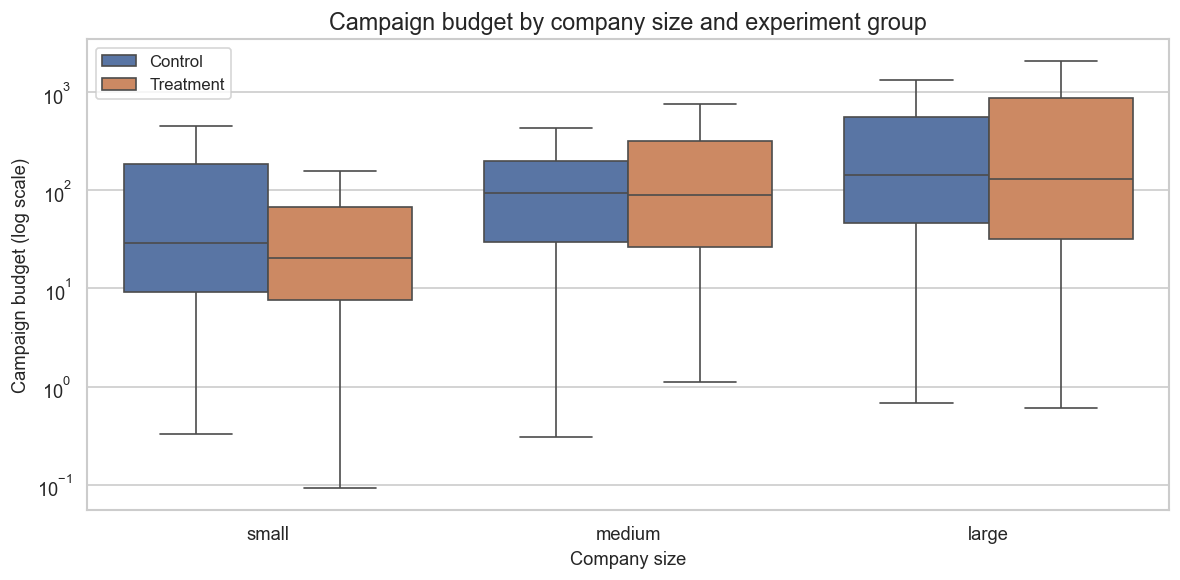

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x="company_size", y="campaign_budget",
    hue="group", order=SIZE_ORDER, hue_order=GROUP_ORDER,
    showfliers=False, ax=ax
)
ax.set_yscale("log")
ax.set_title("Campaign budget by company size and experiment group")
ax.set_xlabel("Company size")
ax.set_ylabel("Campaign budget (log scale)")
ax.legend(title="")
plt.tight_layout()
plt.show()


### Budget difference by company size

This is a useful robustness check because company size is related to advertiser scale. It helps determine whether the overall budget difference is simply reflecting different group composition.


In [22]:
budget_by_size = (
    df.groupby(["company_size", "group"])["campaign_budget"]
      .agg(mean="mean", median="median", count="size")
      .reset_index()
)
budget_by_size


C:\Users\USER\AppData\Local\Temp\ipykernel_1864\904464557.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["company_size", "group"])["campaign_budget"]


,company_size,group,mean,median,count
0,large,Control,"5,933.9692",145.3752,2701
1,large,Treatment,"17,561.8260",129.8792,2445
2,medium,Control,"6,342.8550",95.2264,735
3,medium,Treatment,"4,612.6709",90.5936,692
4,small,Control,"3,538.6558",28.9892,4297
5,small,Treatment,"1,585.4799",20.2882,4604


### Interpretation

If treatment budgets are statistically lower, that is evidence of a budget distribution difference. It is **not** evidence by itself that advertisers lowered budgets because they were wary of the new product. Establishing that motivation would require additional information, such as pre-experiment budgets, advertiser surveys, or a pre-treatment baseline.


# Question 4 — Average overspend percentage

We report the signed overspend percentage because that is the direct `(spend - budget) / budget` measure. Since underspending creates negative values and extreme campaigns can heavily affect the mean, we also report the median and the non-negative actual-overspend measure.


In [36]:
# Q4: Mean and median overspend percentage
q4 = (
    df.groupby("group")
      .agg(
          mean_signed_overspend_pct=("overspend_pct", "mean"),
          median_signed_overspend_pct=("overspend_pct", "median"),
          mean_actual_overspend_pct=("actual_overspend_pct", "mean"),
          median_actual_overspend_pct=("actual_overspend_pct", "median")
      )
)
display(q4)

# Mann–Whitney U test on signed overspend percentage
u_q4, p_q4 = stats.mannwhitneyu(
    df.loc[df["group"] == "Treatment", "overspend_pct"],
    df.loc[df["group"] == "Control", "overspend_pct"],
    alternative="two-sided"
)

print(f"Mann–Whitney U on signed overspend_pct: U={u_q4:.3e}, p={p_q4:.3e}")

,mean_signed_overspend_pct,median_signed_overspend_pct,mean_actual_overspend_pct,median_actual_overspend_pct
group,,,,
Control,25.3226,6.4551,31.3230,6.4551
Treatment,17.6064,4.6265,25.9334,4.6265


Mann–Whitney U on signed overspend_pct: U=2.714e+07, p=1.009e-23


### Visual — Average versus typical overspend

The mean can be strongly affected by extreme campaigns. Showing mean and median together makes that distinction transparent.

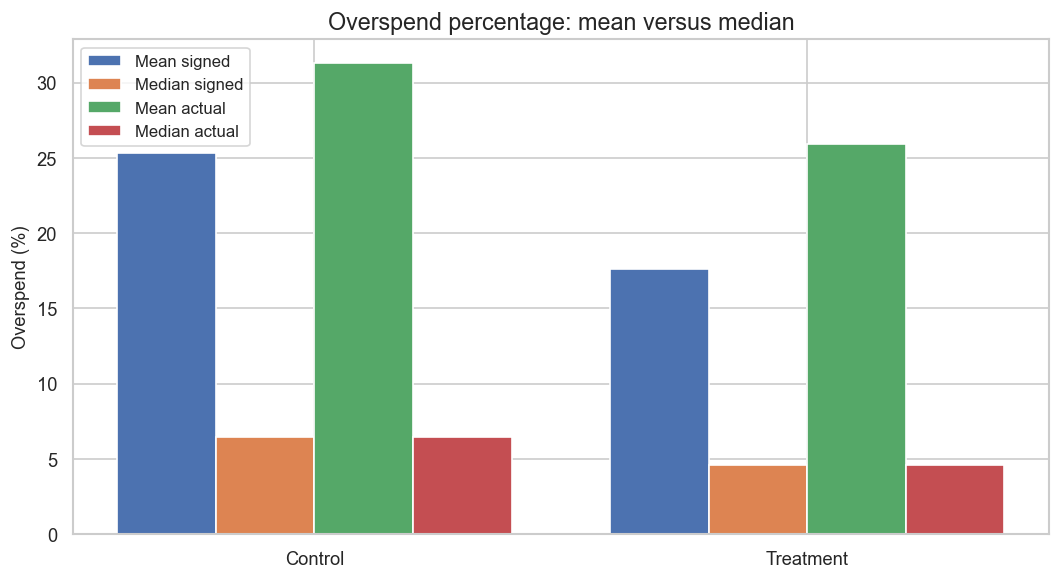

In [24]:
q4_plot = (
    df.groupby("group")
      .agg(
          mean_signed=("overspend_pct", "mean"),
          median_signed=("overspend_pct", "median"),
          mean_actual=("actual_overspend_pct", "mean"),
          median_actual=("actual_overspend_pct", "median")
      )
      .reindex(GROUP_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(q4_plot))
width = 0.2

ax.bar(x - 1.5*width, q4_plot["mean_signed"], width, label="Mean signed")
ax.bar(x - 0.5*width, q4_plot["median_signed"], width, label="Median signed")
ax.bar(x + 0.5*width, q4_plot["mean_actual"], width, label="Mean actual")
ax.bar(x + 1.5*width, q4_plot["median_actual"], width, label="Median actual")

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel("Overspend (%)")
ax.set_xlabel("")
ax.set_title("Overspend percentage: mean versus median")
ax.legend()
plt.tight_layout()
plt.show()


# Question 5 — Click-through rate (CTR)

CTR cannot be calculated from the supplied data.

The standard relationship is:

`CTR = clicks / impressions`

The dataset contains neither clicks nor impressions. We therefore do not invent or estimate CTR from unrelated variables.


# Question 6 — Demographic/business factors associated with overspending

The supplied dataset contains **company size**, but not industry. We therefore analyze company size and explicitly flag industry as unavailable.

We examine company-size differences separately in control and treatment, while keeping the distinction between association and causal effect.


In [25]:
q6_summary = (
    df.groupby(["group", "company_size"])
      .agg(
          campaigns=("overspend_pct", "size"),
          mean_overspend_pct=("overspend_pct", "mean"),
          median_overspend_pct=("overspend_pct", "median"),
          overspend_gt1_rate=("overspent_gt1pct", "mean")
      )
      .reset_index()
)
q6_summary["overspend_gt1_rate"] *= 100
q6_summary


C:\Users\USER\AppData\Local\Temp\ipykernel_1864\2664004785.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["group", "company_size"])


,group,company_size,campaigns,mean_overspend_pct,median_overspend_pct,overspend_gt1_rate
0,Control,large,2701,12.2937,4.0155,69.4187
1,Control,medium,735,4.5570,2.2436,61.4966
2,Control,small,4297,37.0642,12.9946,78.8690
3,Treatment,large,2445,3.2640,2.5053,61.5133
4,Treatment,medium,692,5.1444,2.4708,59.8266
5,Treatment,small,4604,27.0961,7.7651,70.8514


In [26]:
for group in ["Control", "Treatment"]:
    subset = df[df["group"] == group]
    groups = [
        subset.loc[subset["company_size"] == s, "overspend_pct"]
        for s in ["small", "medium", "large"]
    ]
    h, p = stats.kruskal(*groups)
    print(f"{group}: Kruskal-Wallis H={h:.3f}, p={p:.3e}")


Control: Kruskal-Wallis H=438.323, p=6.598e-96
Treatment: Kruskal-Wallis H=270.428, p=1.894e-59


### Interpretation

A significant Kruskal–Wallis test indicates that at least one company-size group's overspend distribution differs from another within that advertising model. It does not, by itself, identify which pairs differ; pairwise follow-up tests would be needed if that distinction is important.


### Visual — Company-size relationship with overspending

This chart directly supports the company-size analysis. It shows the percentage of campaigns exceeding the 1% threshold for each company-size/model combination.

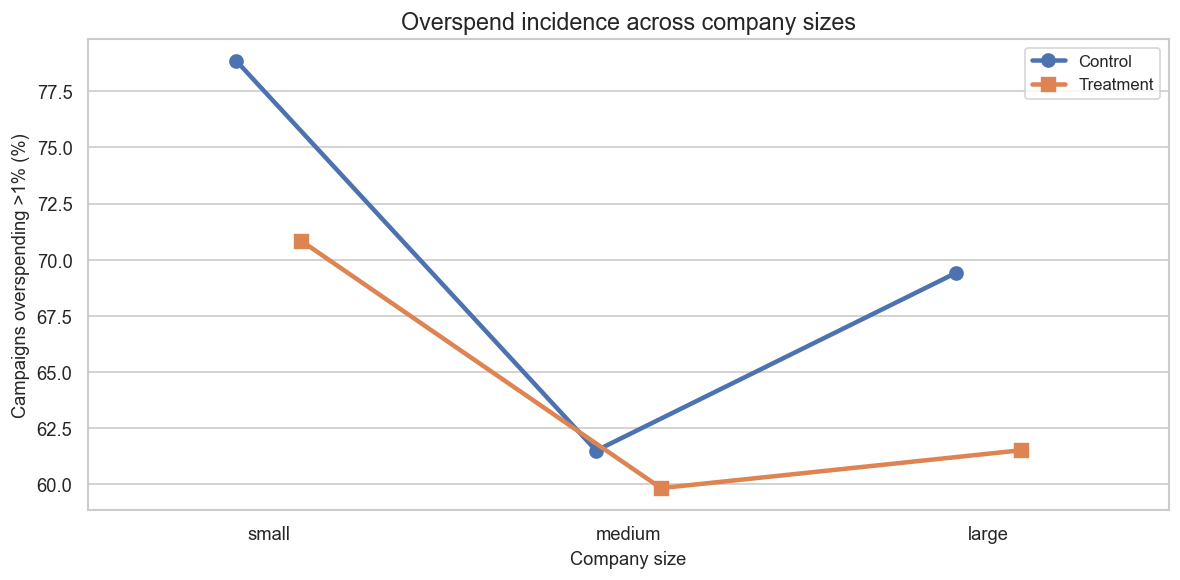

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(
    data=size_rate, x="company_size", y="overspent_gt1pct",
    hue="group", order=SIZE_ORDER, hue_order=GROUP_ORDER,
    dodge=0.18, markers=["o", "s"], linestyles=["-", "-"], ax=ax
)
ax.set_title("Overspend incidence across company sizes")
ax.set_xlabel("Company size")
ax.set_ylabel("Campaigns overspending >1% (%)")
ax.legend(title="")
plt.tight_layout()
plt.show()


# Question 7 — Engagement metrics

The dataset does not contain likes, retweets, or replies. Therefore engagement differences cannot be measured from the supplied files.


# Question 8 — Is percentage of budget spent significantly different?

We define:

`percentage of budget spent = campaign_spend / campaign_budget × 100`

Because this ratio is highly skewed, we report robust descriptive statistics and use a Mann–Whitney comparison as the primary distributional test. A Welch test on the log-transformed ratio is provided as a sensitivity analysis where the transformation is defined.


In [28]:
ratio_summary = (
    df.groupby("group")["budget_spent_pct"]
      .agg(["mean", "median", "std", "min", "max"])
)
ratio_summary


,mean,median,std,min,max
group,,,,,
Control,125.3226,106.4551,73.8715,50.0121,500.0307
Treatment,117.6064,104.6265,69.8348,42.5142,500.0815


In [29]:
c_ratio = df.loc[df["group"] == "Control", "budget_spent_pct"]
t_ratio = df.loc[df["group"] == "Treatment", "budget_spent_pct"]

u_ratio, p_ratio = stats.mannwhitneyu(
    t_ratio, c_ratio, alternative="two-sided"
)

# Log ratio is only appropriate for positive spend/budget ratios.
# The dataset has positive spend and budget, so all ratios are positive.
log_ratio_c = np.log1p(c_ratio)
log_ratio_t = np.log1p(t_ratio)

t_ratio_log, p_ratio_log = stats.ttest_ind(
    log_ratio_t, log_ratio_c, equal_var=False
)

print(f"Mann–Whitney U: U={u_ratio:.3e}, p={p_ratio:.3e}")
print(f"Welch t-test on log(1 + spend/budget): t={t_ratio_log:.3f}, p={p_ratio_log:.3e}")


Mann–Whitney U: U=2.714e+07, p=1.010e-23
Welch t-test on log(1 + spend/budget): t=-9.529, p=1.815e-21


### Interpretation

The median is especially useful here because a small budget can produce an extremely large spend-to-budget ratio. We therefore avoid basing the business conclusion solely on the raw mean.


### Visual — Percentage of budget spent

A value of 100% means the campaign spent exactly its budget. Values above 100% indicate overspending. The median is shown through the boxplot, while extreme values are suppressed from the visible whisker range to keep the typical distribution readable.

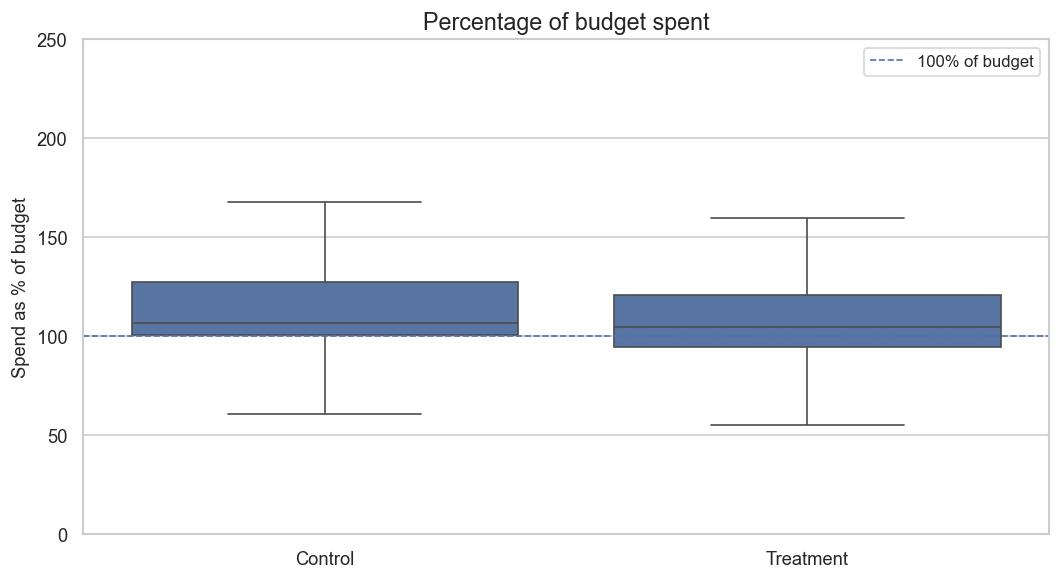

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x="group", y="budget_spent_pct",
    order=GROUP_ORDER, showfliers=False, ax=ax
)
ax.axhline(100, linestyle="--", linewidth=1, label="100% of budget")
ax.set_ylim(0, 250)
ax.set_title("Percentage of budget spent")
ax.set_xlabel("")
ax.set_ylabel("Spend as % of budget")
ax.legend()
plt.tight_layout()
plt.show()


# Question 9 — Does company size significantly affect overspend percentage?

We test company-size differences separately within control and treatment using Kruskal–Wallis tests, consistent with the skewed outcome.

This question is distinct from Q2: Q9 asks whether company size is associated with overspend within each model; Q2 asks whether the **treatment effect itself changes by company size**.


In [31]:
q9_results = []

for group in ["Control", "Treatment"]:
    subset = df[df["group"] == group]
    values = [
        subset.loc[subset["company_size"] == s, "overspend_pct"]
        for s in ["small", "medium", "large"]
    ]
    h, p = stats.kruskal(*values)
    q9_results.append({
        "group": group,
        "kruskal_h": h,
        "p_value": p
    })

pd.DataFrame(q9_results)


,group,kruskal_h,p_value
0,Control,438.3227,0.0000
1,Treatment,270.4278,0.0000


### Visual — Company-size differences in overspend

The same outcome is displayed on a company-size × treatment grid so the reader can see the pattern before reviewing the Kruskal–Wallis test results.

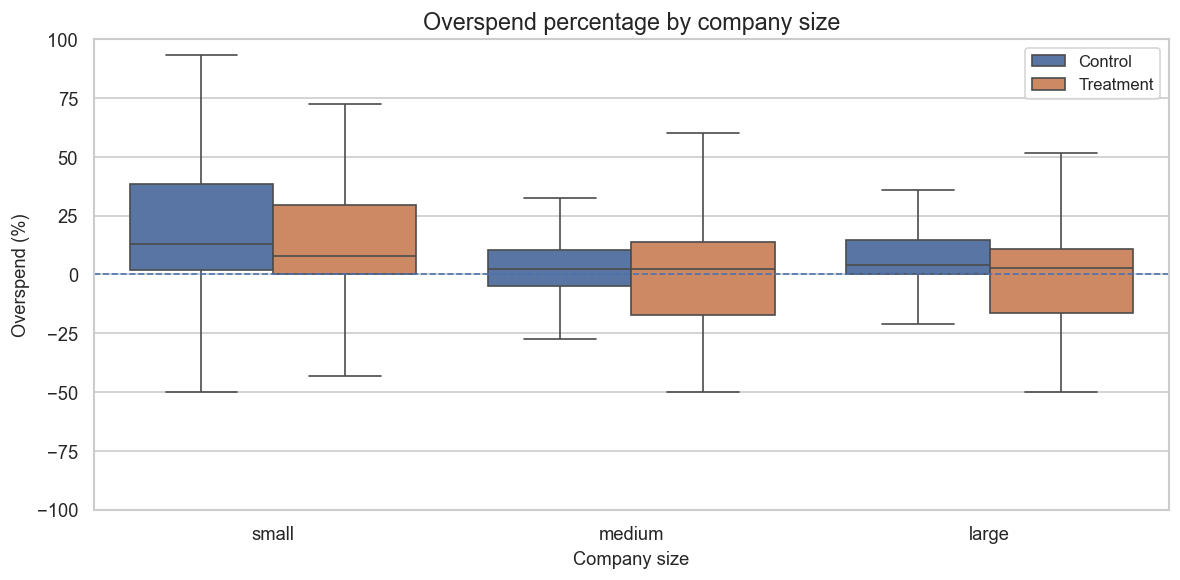

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x="company_size", y="overspend_pct",
    hue="group", order=SIZE_ORDER, hue_order=GROUP_ORDER,
    showfliers=False, ax=ax
)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylim(-100, 100)
ax.set_title("Overspend percentage by company size")
ax.set_xlabel("Company size")
ax.set_ylabel("Overspend (%)")
ax.legend(title="")
plt.tight_layout()
plt.show()


# Question 10 — Is spend variance significantly different?

Raw spend is extremely skewed, so a classical F-test is not appropriate as the sole variance test.

We use Levene's test with the median as the center (Brown–Forsythe form), which is more robust to non-normality, and compare the observed variances as a descriptive measure.


In [33]:
control_spend = df.loc[df["group"] == "Control", "campaign_spend"]
treatment_spend = df.loc[df["group"] == "Treatment", "campaign_spend"]

var_control = control_spend.var(ddof=1)
var_treatment = treatment_spend.var(ddof=1)

levene_stat, levene_p = stats.levene(
    control_spend, treatment_spend, center="median"
)

print(f"Control variance:   {var_control:,.2f}")
print(f"Treatment variance: {var_treatment:,.2f}")
print(f"Variance ratio (Treatment / Control): {var_treatment / var_control:.3f}")
print(f"Brown–Forsythe/Levene statistic: {levene_stat:.3f}")
print(f"p-value: {levene_p:.4f}")


Control variance:   1,157,680,892.35
Treatment variance: 7,331,319,045.59
Variance ratio (Treatment / Control): 6.333
Brown–Forsythe/Levene statistic: 3.328
p-value: 0.0681


### Visual — Spend dispersion

Spend is highly right-skewed. The log-scale distributions make the relative spread between treatment and control easier to inspect without allowing a few million-dollar campaigns to dominate the figure.

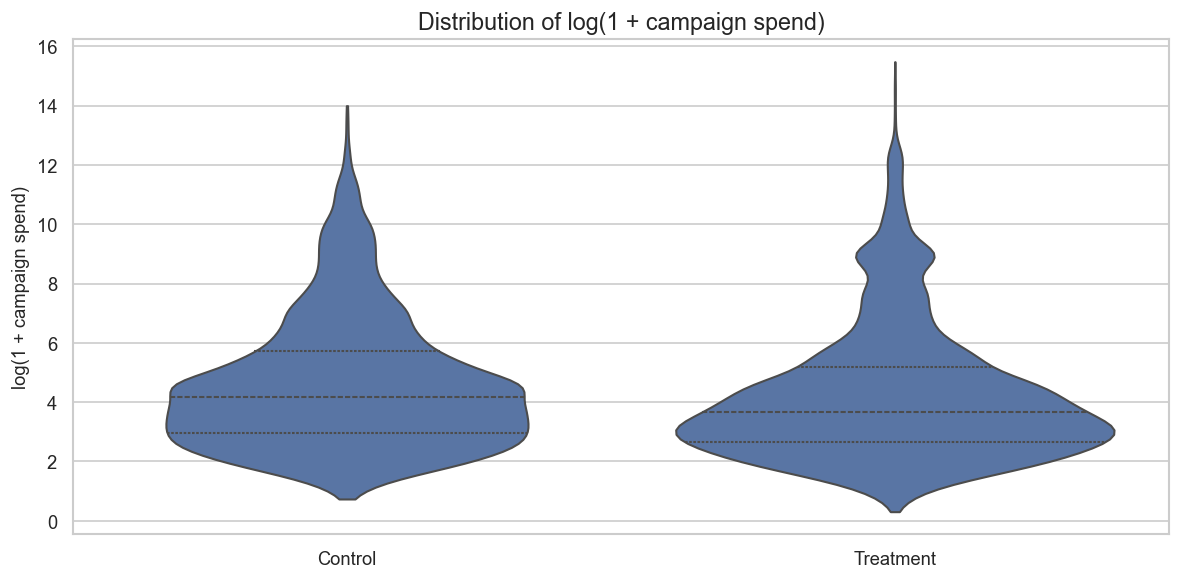

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df, x="group", y="log_spend",
    order=GROUP_ORDER, inner="quartile", cut=0, ax=ax
)
ax.set_title("Distribution of log(1 + campaign spend)")
ax.set_xlabel("")
ax.set_ylabel("log(1 + campaign spend)")
plt.tight_layout()
plt.show()


## Decision-ready results table

This table consolidates the main outcome metrics so a product manager can review the evidence without searching through individual sections.

In [35]:
decision_table = pd.DataFrame({
    "Metric": [
        "Campaigns >1% over budget",
        "Median overspend %",
        "Median % of budget spent",
        "Median campaign budget"
    ],
    "Control": [
        f'{control.mean()*100:.1f}%',
        f'{df.loc[df.group=="Control","overspend_pct"].median():.2f}%',
        f'{df.loc[df.group=="Control","budget_spent_pct"].median():.2f}%',
        f'${df.loc[df.group=="Control","campaign_budget"].median():,.2f}'
    ],
    "Treatment": [
        f'{treatment.mean()*100:.1f}%',
        f'{df.loc[df.group=="Treatment","overspend_pct"].median():.2f}%',
        f'{df.loc[df.group=="Treatment","budget_spent_pct"].median():.2f}%',
        f'${df.loc[df.group=="Treatment","campaign_budget"].median():,.2f}'
    ]
})
decision_table


,Metric,Control,Treatment
0,Campaigns >1% over budget,73.9%,66.9%
1,Median overspend %,6.46%,4.63%
2,Median % of budget spent,106.46%,104.63%
3,Median campaign budget,$65.38,$38.59


# Overall interpretation

The analysis should separate three ideas:

1. **Direction:** Is treatment associated with less overspending?
2. **Magnitude:** How large is the difference?
3. **Heterogeneity:** Does the treatment effect differ by company size?

We also distinguish statistical evidence from causal explanations. In particular, a budget difference does not establish why advertisers selected those budgets.

The supplied data support analysis of overspending, budgets, spend, company size, and treatment assignment. They do not support CTR, engagement, or industry analysis.


# Data limitations

The supplied data contain only four variables:

- `treatment`
- `company_size`
- `campaign_spend`
- `campaign_budget`

Missing variables prevent direct analysis of:

- clicks
- impressions
- CTR
- likes
- retweets
- replies
- industry

Additional pre-experiment data would also improve the ability to assess baseline budget behavior and investigate whether treatment advertisers changed budgets after assignment.
